# Sprint 3 — Baseline models

    Entrena modelos baseline con muestra estratificada. No hay tuning en este sprint.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import *
from src.io_utils import load_kick_data, save_df
from src.preprocessing import prepare_features, split_X_y

pd.set_option('display.max_columns', 120)
print('Proyecto:', PROJECT_ROOT)

from src.models import build_baseline_models, train_and_evaluate_baselines

Proyecto: c:\Users\PONCE\dp261-g1


In [2]:
train_sample = pd.read_csv(PROCESSED_DIR / 'train_sample.csv')
X_sample, y_sample = split_X_y(train_sample)
print(X_sample.shape, y_sample.mean())

(20000, 38) 0.123


Debido al desbalance de clases del problema (IsBadBuy ≈ 12.3%), la evaluación de modelos no se basará únicamente en accuracy.

Se priorizan métricas orientadas a la detección de vehículos problemáticos:

Recall: capacidad de detectar casos positivos (BadBuy)
Precision: proporción de positivos correctamente identificados
F2-score: métrica que prioriza Recall sobre Precision
ROC-AUC: capacidad discriminativa general del modelo

In [3]:
models = build_baseline_models(X_sample)
results, fitted = train_and_evaluate_baselines(models, X_sample, y_sample, save_models=True)
results = results.sort_values(
    ["recall_cv_mean", "f2_cv_mean", "precision_cv_mean"],
    ascending=[False, False, False]
)
display(results)
results.to_csv(REPORTS_DIR / 'baseline_cv_results.csv', index=False)

,model,fit_time_mean,accuracy_cv_mean,accuracy_cv_std,accuracy_train_mean,accuracy_gap,precision_cv_mean,precision_cv_std,precision_train_mean,precision_gap,recall_cv_mean,recall_cv_std,recall_train_mean,recall_gap,f1_cv_mean,f1_cv_std,f1_train_mean,f1_gap,f05_cv_mean,f05_cv_std,f05_train_mean,f05_gap,f2_cv_mean,f2_cv_std,f2_train_mean,f2_gap,roc_auc_cv_mean,roc_auc_cv_std,roc_auc_train_mean,roc_auc_gap,average_precision_cv_mean,average_precision_cv_std,average_precision_train_mean,average_precision_gap,status,seconds_total,model_path
2,DecisionTree,1.912332,0.82225,0.006971,1.000000,0.177750,0.305497,0.018620,1.000000,0.694503,0.347967,0.013869,1.000000,0.652033,0.325238,0.015836,1.000000,0.674762,0.313077,0.017506,1.000000,0.686923,0.338472,0.014418,1.000000,0.661528,0.618368,0.009128,1.000000,0.381632,0.186710,0.008531,1.000000,0.813290,ok,10.9,c:\Users\PONCE\dp261-g1\models\baseline_Decisi...
4,LinearSVM,0.753237,0.89620,0.002754,0.896437,0.000238,0.712536,0.022333,0.715991,0.003455,0.260976,0.021762,0.261890,0.000915,0.381734,0.025962,0.383484,0.001751,0.528850,0.026535,0.531594,0.002744,0.298764,0.023460,0.299929,0.001165,0.747773,0.016567,0.770130,0.022357,0.436505,0.034994,0.458244,0.021739,ok,5.2,c:\Users\PONCE\dp261-g1\models\baseline_Linear...
1,LogisticRegression,0.441405,0.89655,0.002754,0.897650,0.001100,0.734599,0.029665,0.749129,0.014530,0.248780,0.018342,0.252439,0.003659,0.371430,0.022971,0.377592,0.006162,0.527809,0.025971,0.537519,0.009710,0.286626,0.020043,0.291021,0.004394,0.749111,0.016304,0.771170,0.022059,0.437196,0.033282,0.459838,0.022642,ok,3.5,c:\Users\PONCE\dp261-g1\models\baseline_Logist...
6,GradientBoosting,8.117623,0.90145,0.003076,0.905738,0.004288,0.836724,0.033475,0.888160,0.051436,0.246748,0.018432,0.267276,0.020528,0.380922,0.024881,0.410856,0.029934,0.565646,0.030100,0.606330,0.040684,0.287207,0.020633,0.310707,0.023501,0.760120,0.014057,0.811152,0.051031,0.467894,0.025497,0.551544,0.083650,ok,42.0,c:\Users\PONCE\dp261-g1\models\baseline_Gradie...
7,HistGradientBoosting,1.512579,0.90210,0.002327,0.908862,0.006762,0.870166,0.026025,0.937089,0.066924,0.239837,0.015479,0.277642,0.037805,0.375832,0.020427,0.428301,0.052469,0.569916,0.023483,0.635162,0.065247,0.280418,0.017232,0.323101,0.042683,0.760755,0.014343,0.910077,0.149322,0.471401,0.024301,0.721738,0.250338,ok,10.4,c:\Users\PONCE\dp261-g1\models\baseline_HistGr...
3,RandomForest,3.350623,0.90195,0.002605,0.999987,0.098037,0.886383,0.030830,1.000000,0.113617,0.232520,0.015243,0.999898,0.767378,0.368274,0.021290,0.999949,0.631675,0.567020,0.026791,0.999980,0.432960,0.272730,0.017245,0.999919,0.727189,0.749066,0.019276,1.000000,0.250934,0.455572,0.027195,1.000000,0.544428,ok,19.2,c:\Users\PONCE\dp261-g1\models\baseline_Random...
5,KNN,0.300820,0.87715,0.000464,0.878688,0.001538,0.530909,0.087121,0.762611,0.231702,0.011382,0.001626,0.019919,0.008537,0.022285,0.003190,0.038821,0.016536,0.052407,0.007549,0.090153,0.037746,0.014152,0.002023,0.024736,0.010585,0.650081,0.022190,0.811727,0.161646,0.211755,0.012429,0.359883,0.148129,ok,89.3,c:\Users\PONCE\dp261-g1\models\baseline_KNN.pkl
0,Dummy_most_frequent,0.256726,0.87700,0.000000,0.877000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.123000,0.000000,0.123000,0.000000,ok,2.5,c:\Users\PONCE\dp261-g1\models\baseline_Dummy_...


In [4]:
overfit_cols = [
    'model',
    'recall_gap',
    'precision_gap',
    'roc_auc_gap'
]

display(
    results[overfit_cols]
    .sort_values('recall_gap', ascending=False)
)

,model,recall_gap,precision_gap,roc_auc_gap
3,RandomForest,0.767378,0.113617,0.250934
2,DecisionTree,0.652033,0.694503,0.381632
7,HistGradientBoosting,0.037805,0.066924,0.149322
6,GradientBoosting,0.020528,0.051436,0.051031
5,KNN,0.008537,0.231702,0.161646
1,LogisticRegression,0.003659,0.014530,0.022059
4,LinearSVM,0.000915,0.003455,0.022357
0,Dummy_most_frequent,0.000000,0.000000,0.000000


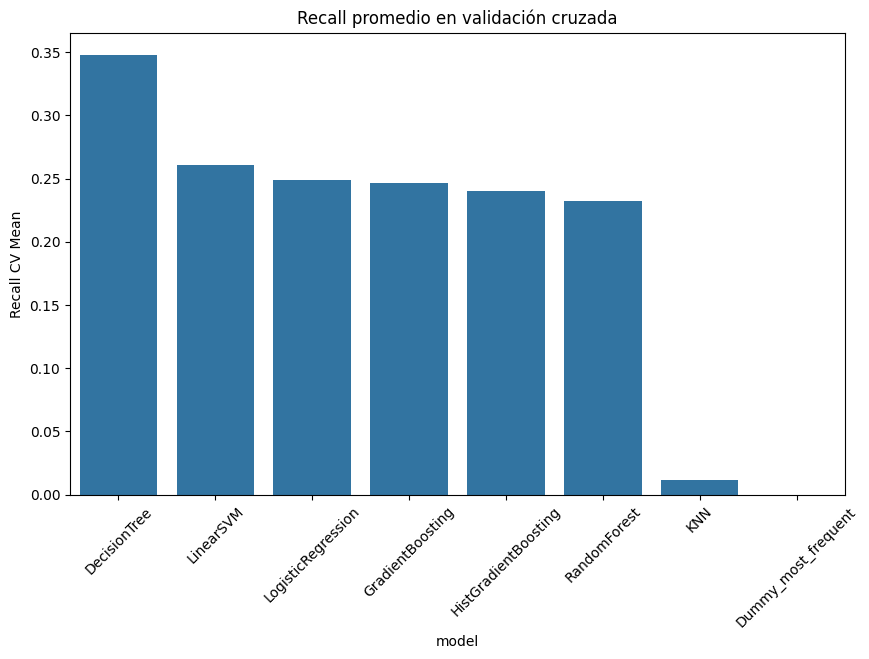

In [5]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='model',
    y='recall_cv_mean'
)

plt.xticks(rotation=45)
plt.title('Recall promedio en validación cruzada')
plt.ylabel('Recall CV Mean')

plt.show()

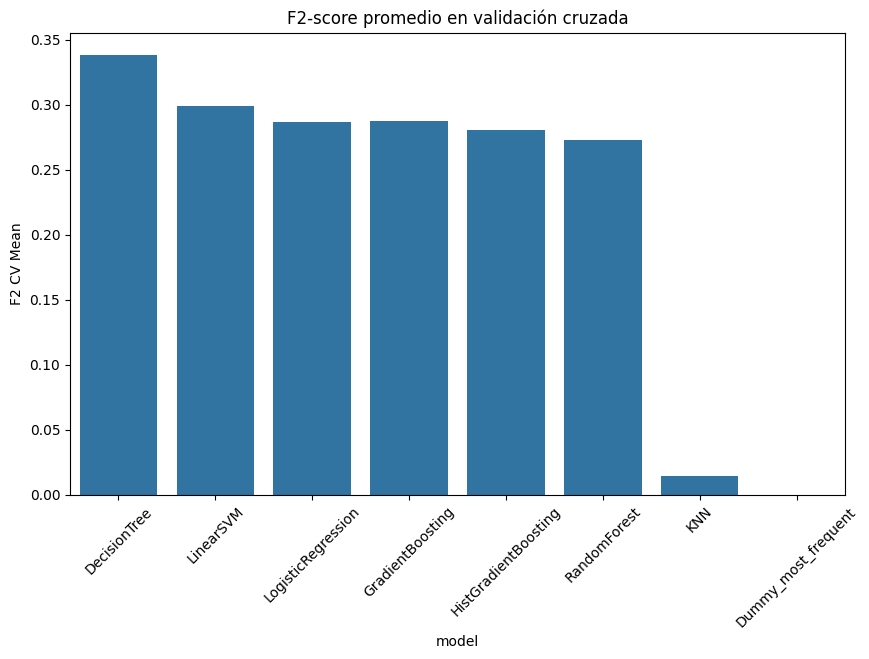

In [6]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=results,
    x='model',
    y='f2_cv_mean'
)

plt.xticks(rotation=45)
plt.title('F2-score promedio en validación cruzada')
plt.ylabel('F2 CV Mean')

plt.show()